In [18]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ML imports
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# notebook display settings
%matplotlib inline
sns.set_style("whitegrid")
sns.set_palette("husl")


data_dir   = "../data/cleaned/"
output_dir = "../outputs/figures/"
model_dir  = "../outputs/models/"

for d in [output_dir, model_dir]:
    os.makedirs(d, exist_ok=True)

print("setup complete")

setup complete


In [19]:
# loading files

temp_df = pd.read_csv(data_dir + "temp_anomaly_clean.csv")
co2_df  = pd.read_csv(data_dir + "co2_emissions_clean.csv")


print("temperature dataset")
print(temp_df.head(3))
print(f"shape: {temp_df.shape}\n")

print("co2 emissions dataset")
print(co2_df.head(3))
print(f"shape: {co2_df.shape}")

temperature dataset
  year_month  year  month               region  temp_anomaly_c  \
0    2000-01  2000      1               Global           0.432   
1    2000-01  2000      1               Arctic           1.500   
2    2000-01  2000      1  Northern_Hemisphere           0.468   

  temp_anomaly_baseline  co2_ppm  
0             1951-1980   367.44  
1             1951-1980   367.44  
2             1951-1980   367.44  
shape: (2528, 7)

co2 emissions dataset
   year  country iso3 region  co2_emissions_mt  population_millions  \
0  2000  Algeria  DZA   MENA             102.0                 38.2   
1  2001  Algeria  DZA   MENA             103.0                 38.6   
2  2002  Algeria  DZA   MENA             105.4                 38.9   

   co2_per_capita_t  co2_intensity_kg_per_gdp_usd  
0              2.67                          0.53  
1              2.67                          0.49  
2              2.71                          0.45  
shape: (1350, 8)


In [20]:
#  Predicting monthly global temperature anomaly


global_records = temp_df[temp_df["region"] == "Global"].copy()  # isolate global measurements only


global_records = global_records.dropna(subset=["co2_ppm", "temp_anomaly_c"]) # remove missing records

# build aggregated co2 features
yearly_totals = (
    co2_df
    .groupby("year")
    .agg(
        world_co2_mt    = ("co2_emissions_mt",  "sum"),
        mean_per_capita = ("co2_per_capita_t",  "mean"),
        num_countries   = ("country",            "nunique")
    )
    .reset_index()
)

# join them on year
combined = global_records.merge(yearly_totals, on="year", how="left")

print(f"final table: {combined.shape[0]} rows x {combined.shape[1]} columns")
print(combined.head())

final table: 316 rows x 10 columns
  year_month  year  month  region  temp_anomaly_c temp_anomaly_baseline  \
0    2000-01  2000      1  Global           0.432             1951-1980   
1    2000-02  2000      2  Global           0.451             1951-1980   
2    2000-03  2000      3  Global           0.428             1951-1980   
3    2000-04  2000      4  Global           0.484             1951-1980   
4    2000-05  2000      5  Global           0.488             1951-1980   

   co2_ppm  world_co2_mt  mean_per_capita  num_countries  
0   367.44       22788.8           7.3992             50  
1   369.21       22788.8           7.3992             50  
2   371.01       22788.8           7.3992             50  
3   372.55       22788.8           7.3992             50  
4   373.24       22788.8           7.3992             50  


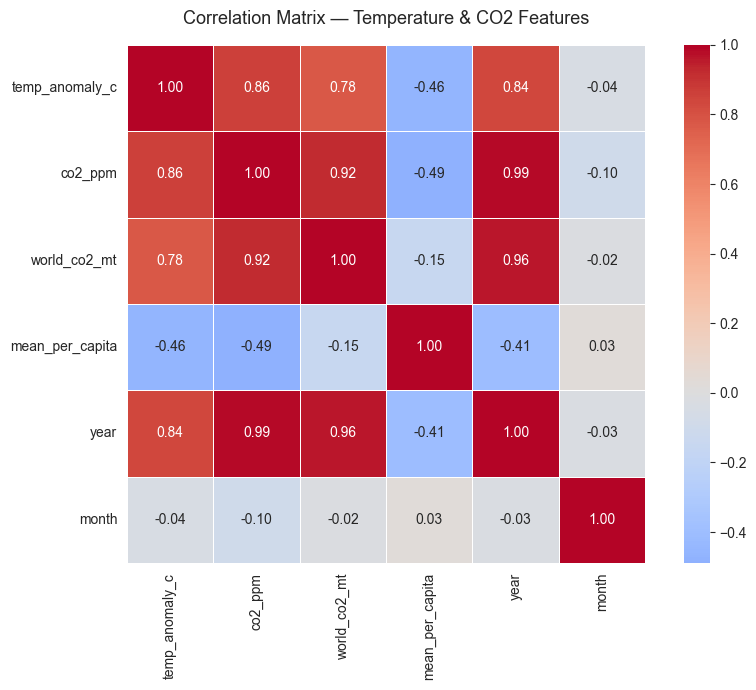

strong correlations with temp_anomaly_c suggest good predictive features


In [21]:
#  Checking correlations


cols_to_check = [
    "temp_anomaly_c", "co2_ppm",
    "world_co2_mt", "mean_per_capita", "year", "month"
]

subset = combined[cols_to_check].dropna()

fig, ax = plt.subplots(figsize=(9, 7))

correlation_matrix = subset.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Matrix — Temperature & CO2 Features", 
             fontsize=13, pad=15)

plt.tight_layout()
plt.savefig(output_dir + "14_correlation_heatmap.png", dpi=150)
plt.show()

print("strong correlations with temp_anomaly_c suggest good predictive features")

In [22]:
# picking the input and predict

input_cols = ["year", "month", "co2_ppm", "world_co2_mt", "mean_per_capita"]
output_col = "temp_anomaly_c"

# drop any remaining nulls
model_df = combined[input_cols + [output_col]].dropna()

X = model_df[input_cols]
y = model_df[output_col]

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\ny statistics:")
print(y.describe().round(3))

X shape : (316, 5)
y shape : (316,)

y statistics:
count    316.000
mean       0.780
std        0.235
min        0.401
25%        0.601
50%        0.696
75%        0.928
max        1.455
Name: temp_anomaly_c, dtype: float64


In [23]:
# splitting data — 75% train, 25% test


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0
)

print(f"training samples : {len(X_train)}")
print(f"test samples     : {len(X_test)}")

training samples : 237
test samples     : 79


In [24]:
# using MinMaxScaler range [0, 1]
# this is different from StandardScaler(mean/std) 


scaler = MinMaxScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(" Done. features in range [0, 1]")

 Done. features in range [0, 1]


In [25]:
# linear regression (baseline) 


lin_reg = LinearRegression()
lin_reg.fit(X_train_sc, y_train)

lin_preds = lin_reg.predict(X_test_sc)

lin_mae  = mean_absolute_error(y_test, lin_preds)
lin_rmse = mean_squared_error(y_test, lin_preds) ** 0.5
lin_r2   = r2_score(y_test, lin_preds)

print("--- Linear Regression Results ---")
print(f"MAE  : {lin_mae:.4f} °C")
print(f"RMSE : {lin_rmse:.4f} °C")
print(f"R²   : {lin_r2:.4f}")

# cross validation gives a more reliable performance estimate
# it tests the model on 5 different splits of the data
cv_scores = cross_val_score(lin_reg, X_train_sc, y_train, cv=5, scoring="r2")
print(f"\ncross-validation R² scores : {cv_scores.round(3)}")
print(f"average CV R²              : {cv_scores.mean():.4f}")

--- Linear Regression Results ---
MAE  : 0.0856 °C
RMSE : 0.1074 °C
R²   : 0.7720

cross-validation R² scores : [0.689 0.857 0.541 0.694 0.705]
average CV R²              : 0.6973


In [26]:
# random forest


rf_reg = RandomForestRegressor(
    n_estimators=200,    
    max_depth=10,        
    min_samples_leaf=2,  
    random_state=0
)

rf_reg.fit(X_train_sc, y_train)

rf_preds = rf_reg.predict(X_test_sc)

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_r2   = r2_score(y_test, rf_preds)

print("--- Random Forest Results ---")
print(f"MAE  : {rf_mae:.4f} °C")
print(f"RMSE : {rf_rmse:.4f} °C")
print(f"R²   : {rf_r2:.4f}")

cv_scores_rf = cross_val_score(rf_reg, X_train_sc, y_train, cv=5, scoring="r2")
print(f"\ncross-validation R² scores : {cv_scores_rf.round(3)}")
print(f"average CV R²              : {cv_scores_rf.mean():.4f}")

--- Random Forest Results ---
MAE  : 0.0461 °C
RMSE : 0.0572 °C
R²   : 0.9355

cross-validation R² scores : [0.939 0.929 0.903 0.918 0.925]
average CV R²              : 0.9227


In [27]:
# comparing linearregression with random forest

results = pd.DataFrame({
    "Model" : ["Linear Regression", "Random Forest"],
    "MAE"   : [lin_mae,  rf_mae],
    "RMSE"  : [lin_rmse, rf_rmse],
    "R²"    : [lin_r2,   rf_r2]
})

results = results.round(4)
print(results.to_string(index=False))

# select best model based on R2
best_idx   = results["R²"].idxmax()
best_name  = results.loc[best_idx, "Model"]
print(f"\nbest performing model: {best_name}")

# assign best model for saving and predictions
if best_name == "Random Forest":
    final_model  = rf_reg
    final_preds  = rf_preds
else:
    final_model  = lin_reg
    final_preds  = lin_preds

            Model    MAE   RMSE     R²
Linear Regression 0.0856 0.1074 0.7720
    Random Forest 0.0461 0.0572 0.9355

best performing model: Random Forest


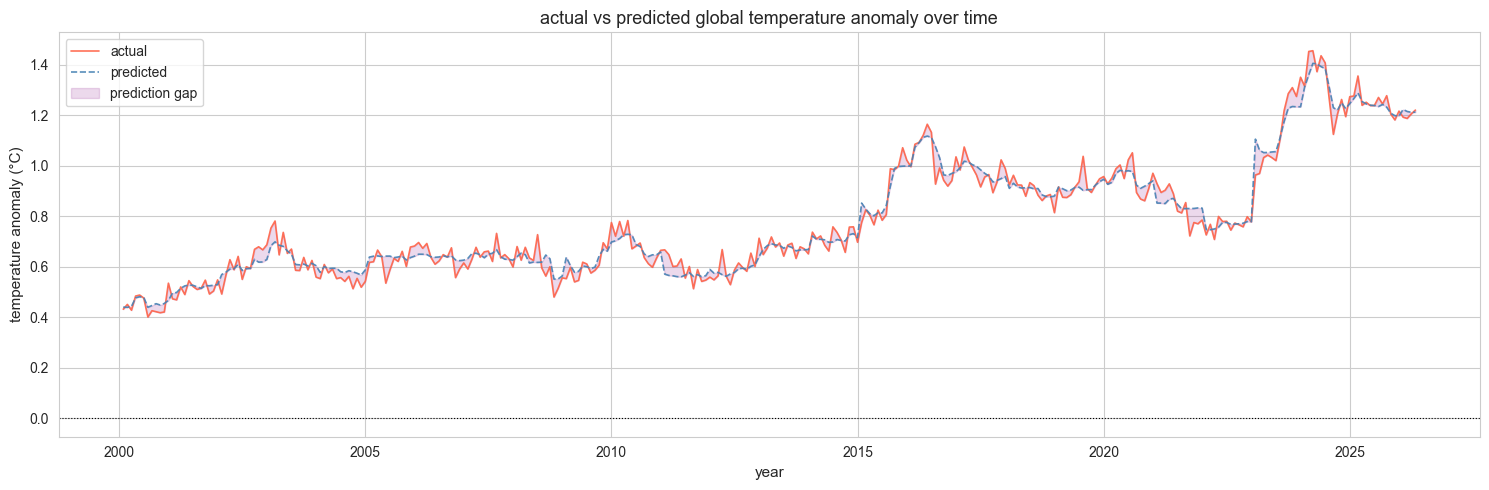

In [28]:
# plotting predictions to values

time_axis = model_df["year"] + model_df["month"] / 12

all_scaled   = scaler.transform(model_df[input_cols])
all_preds    = final_model.predict(all_scaled)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(time_axis, model_df[output_col],
        label="actual", color="tomato", linewidth=1.2, alpha=0.9)

ax.plot(time_axis, all_preds,
        label="predicted", color="steelblue",
        linewidth=1.2, linestyle="--", alpha=0.9)

ax.fill_between(
    time_axis,
    model_df[output_col],
    all_preds,
    alpha=0.15,
    color="purple",
    label="prediction gap"
)

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("year", fontsize=11)
ax.set_ylabel("temperature anomaly (°C)", fontsize=11)
ax.set_title("actual vs predicted global temperature anomaly over time", fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig(output_dir + "15_predicted_vs_actual_time.png", dpi=150)
plt.show()

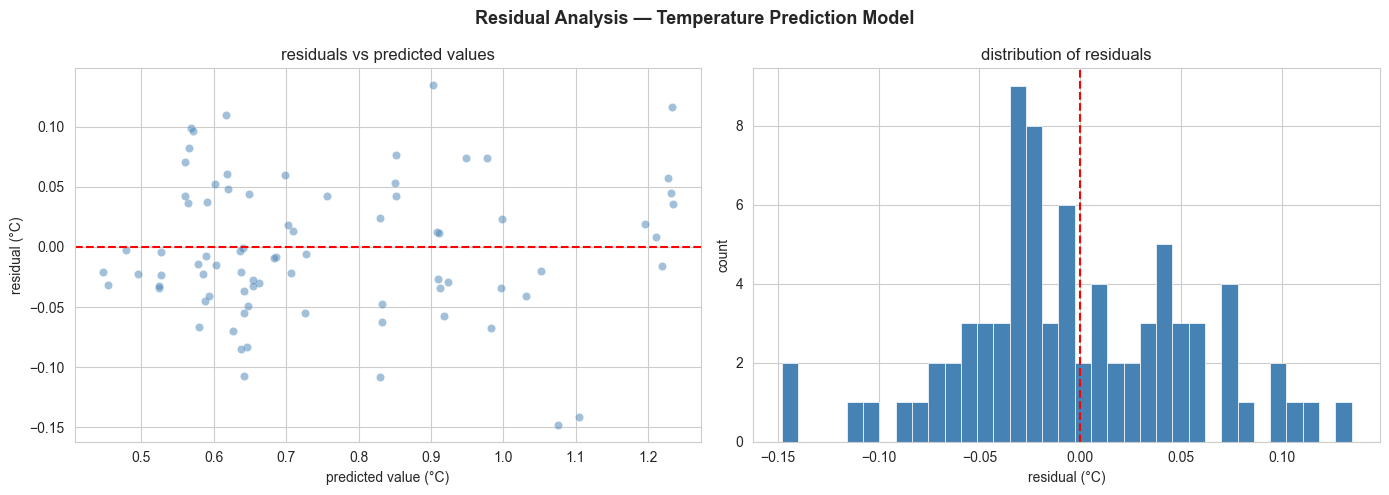

mean residual : -0.0025 °C  (ideally close to 0)
std residual  : 0.0571 °C


In [29]:
#  actual Vs predicted values


residuals = y_test.values - final_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left plot: residuals over prediction value
axes[0].scatter(
    final_preds, residuals,
    alpha=0.5, color="steelblue",
    edgecolors="white", linewidth=0.3, s=35
)
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("predicted value (°C)")
axes[0].set_ylabel("residual (°C)")
axes[0].set_title("residuals vs predicted values")

# right plot: distribution of residuals
axes[1].hist(residuals, bins=35, color="steelblue",
             edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("residual (°C)")
axes[1].set_ylabel("count")
axes[1].set_title("distribution of residuals")

plt.suptitle("Residual Analysis — Temperature Prediction Model",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(output_dir + "16_residuals_analysis.png", dpi=150)
plt.show()

print(f"mean residual : {residuals.mean():.4f} °C  (ideally close to 0)")
print(f"std residual  : {residuals.std():.4f} °C")

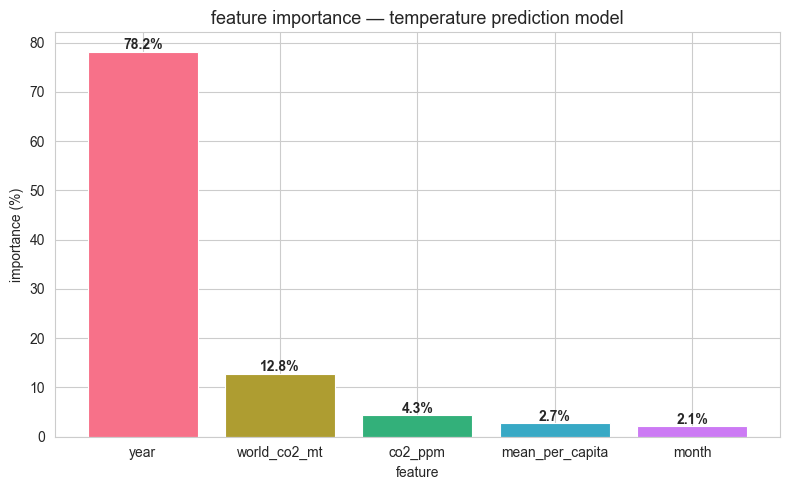

In [30]:
#  features contributing to predictions


feat_imp = pd.Series(
    rf_reg.feature_importances_,
    index=input_cols
).sort_values(ascending=False)

# percentage measurement
feat_imp_pct = (feat_imp / feat_imp.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))

colors = sns.color_palette("husl", len(feat_imp_pct))

bars = ax.bar(
    feat_imp_pct.index,
    feat_imp_pct.values,
    color=colors,
    edgecolor="white",
    linewidth=0.8
)


for bar, val in zip(bars, feat_imp_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("feature importance — temperature prediction model", fontsize=13)
ax.set_ylabel("importance (%)")
ax.set_xlabel("feature")

plt.tight_layout()
plt.savefig(output_dir + "17_feature_importance_temp.png", dpi=150)
plt.show()

In [31]:
# saving the trained model and scaler


joblib.dump(final_model, model_dir + "temp_anomaly_model.pkl")
joblib.dump(scaler,      model_dir + "temp_minmax_scaler.pkl")

print("models saved:")
print(f"  {model_dir}temp_anomaly_model.pkl")
print(f"  {model_dir}temp_minmax_scaler.pkl")

models saved:
  ../outputs/models/temp_anomaly_model.pkl
  ../outputs/models/temp_minmax_scaler.pkl


In [32]:
# using our trained model to forecast temperature anomaly
# future CO2 emissions
# fossil fuel use


future_scenarios = pd.DataFrame({
    "year"          : [2025, 2027, 2030, 2033, 2035],
    "month"         : [6,    6,    6,    6,    6],
    "co2_ppm"       : [425,  428,  433,  438,  442],
    "world_co2_mt"  : [37500, 38000, 39000, 39500, 40000],
    "mean_per_capita": [4.6,  4.6,  4.7,  4.7,  4.8]
})

future_scaled      = scaler.transform(future_scenarios[input_cols])
future_predictions = final_model.predict(future_scaled)

future_scenarios["predicted_temp_anomaly_c"] = future_predictions.round(3)

print("future temperature anomaly forecasts:")
print()
print(future_scenarios[["year", "co2_ppm", "predicted_temp_anomaly_c"]].to_string(index=False))

future temperature anomaly forecasts:

 year  co2_ppm  predicted_temp_anomaly_c
 2025      425                     1.202
 2027      428                     1.184
 2030      433                     1.217
 2033      438                     1.211
 2035      442                     1.211
